# Ausgrid 1: foundation pipeline orchestrator

This notebook is the primary way to run Delivery 1. It follows the same pattern as the `bms_sa_review` orchestrators: tested build modules underneath, a small slice first, visible checks after every stage, and an explicit full-run gate.

```text
inventory -> metadata + ID reconciliation -> duplicate audit
          -> canonical phase telemetry -> validation
```

**Delivery 1 does not calculate Volt-VAr or Volt-Watt conformance.** Those result builders and visual-analysis notebooks are planned in Deliveries 4 and 5.

## How to use this notebook

1. Install the project with the notebook extras.
2. Copy `config/analysis.example.toml` to `analysis.toml` and review it.
3. Run the sample cells from top to bottom.
4. Do not proceed past a failed assertion.
5. Review the conflicting-duplicate sample and canonical plots.
6. Use the full-run section only after the sample validation passes.

Raw parquet and Excel inputs are never modified. `OVERWRITE_SAMPLE` affects only outputs below the configured `derived_root`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Locate the downloaded project whether Jupyter starts in the project root
# or in the notebooks directory.
HERE = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        path
        for path in (HERE, *HERE.parents)
        if (path / "src" / "ausgrid_analysis").is_dir()
    ),
    None,
)
assert PROJECT_ROOT is not None, "Start Jupyter inside the ausgrid_analysis project."
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ausgrid_analysis.canonical import (
    build_canonical_phase,
    canonical_build_summary_path,
)
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import (
    canonical_output_path,
    connect,
    duplicate_audit_path,
    duplicate_summary_path,
)
from ausgrid_analysis.duplicates import conflicting_rows_path, run_duplicate_audit
from ausgrid_analysis.inventory import inventory_output_path, run_inventory
from ausgrid_analysis.metadata import (
    metadata_output_path,
    metadata_summary_path,
    prepare_metadata,
    reconciliation_output_path,
)
from ausgrid_analysis.schemas import sql_string
from ausgrid_analysis.validation import validate_canonical_phase

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# User-controlled settings.
CONFIG_PATH = PROJECT_ROOT / "analysis.toml"
SAMPLE_MONTH = "2025-04"
SAMPLE_BUCKET = 0
OVERWRITE_SAMPLE = False  # Set True only when intentionally rebuilding the sample.

assert CONFIG_PATH.is_file(), (
    "Copy config/analysis.example.toml to analysis.toml and review it first."
)

config = load_config(CONFIG_PATH, check_inputs=True)
scope = config.scope(SAMPLE_MONTH, SAMPLE_BUCKET)

def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

def query(sql: str) -> pd.DataFrame:
    connection = connect(config)
    try:
        return connection.execute(sql).fetchdf()
    finally:
        connection.close()

display(pd.DataFrame({
    "setting": [
        "sample scope", "telemetry", "metadata", "derived outputs",
        "active export sign", "reactive absorption sign", "source timezone",
    ],
    "value": [
        scope.label,
        str(config.paths.telemetry_parquet),
        str(config.paths.metadata_workbook),
        str(config.paths.derived_root),
        config.assumptions.active_export_sign,
        config.assumptions.reactive_absorbing_sign,
        config.assumptions.source_timezone,
    ],
}))

,setting,value
0,sample scope,month_2025_04__bucket_0_of_32
1,telemetry,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...
2,metadata,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...
3,derived outputs,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...
4,active export sign,-1
5,reactive absorption sign,-1
6,source timezone,UTC


## Stage 0: source inventory

This is a read-only scan of the selected month and site bucket. 

Check schema, row count, time coverage, phases and source files before creating derived tables.

In [3]:
inventory = run_inventory(config, scope)

display(pd.DataFrame([inventory["overall"]]))
display(pd.DataFrame(inventory["by_source_month"]))
display(pd.DataFrame(inventory["by_phase"]))
display(pd.DataFrame(inventory["telemetry_schema"])[["column_name", "column_type", "null"]])

2026-07-30 15:54:29,260 | INFO | Inventorying source scope: month_2025_04__bucket_0_of_32
2026-07-30 15:54:30,439 | INFO | Source inventory written to C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\samples\month_2025_04__bucket_0_of_32\_manifests\source_inventory.json


,n_rows,n_serials,first_measure_time,last_measure_time,n_phases,n_source_months,n_source_files,null_timestamps,null_or_blank_serials
0,759287,42,2025-04-01,2025-04-30 23:55:00,3,1,1,0,0


,source_month,n_rows,n_serials,first_measure_time,last_measure_time
0,2025-04,759287,42,2025-04-01,2025-04-30 23:55:00


,phase,n_rows,n_serials
0,A,358547,42
1,B,213250,25
2,C,187490,22


,column_name,column_type,null
0,serial,BIGINT,YES
1,MeasureTime,TIMESTAMP,YES
2,Vphase,VARCHAR,YES
3,Volts,DOUBLE,YES
4,Curr,DOUBLE,YES
5,ReactPow,DOUBLE,YES
6,ActivePow,DOUBLE,YES
7,month,VARCHAR,YES
8,source_file,VARCHAR,YES


In [4]:
# Gate 0: do not continue if source identifiers or timestamps are unusable.
inventory_gate = pd.DataFrame({
    "check": ["rows found", "serials found", "no null timestamps", "no blank serials"],
    "passed": [
        inventory["overall"]["n_rows"] > 0,
        inventory["overall"]["n_serials"] > 0,
        inventory["overall"]["null_timestamps"] == 0,
        inventory["overall"]["null_or_blank_serials"] == 0,
    ],
})
display(inventory_gate)
assert inventory_gate["passed"].all(), "Stage 0 failed; inspect the inventory above."

,check,passed
0,rows found,True
1,serials found,True
2,no null timestamps,True
3,no blank serials,True


## Stage 1: canonical metadata and scoped ID reconciliation

The metadata workbook is normalised once. 

ID reconciliation uses the same sample scope, so this first run does not scan the full 303-million-row parquet. 

Missing metadata is reported but does not remove telemetry.

In [5]:
metadata_report_path = metadata_summary_path(config, scope)
reconciliation_path = reconciliation_output_path(config, scope)

if metadata_report_path.exists() and reconciliation_path.exists() and not OVERWRITE_SAMPLE:
    metadata_report = read_json(metadata_report_path)
    print("Reusing existing scoped metadata report. Set OVERWRITE_SAMPLE=True to rebuild.")
else:
    metadata_report = prepare_metadata(config, scope, overwrite=OVERWRITE_SAMPLE)

display(pd.DataFrame([metadata_report["reconciliation_counts"]]).fillna(0))
display(pd.DataFrame([metadata_report["cohort_counts"]]).fillna(0))

reconciliation = pd.read_csv(reconciliation_path, dtype={"serial": "string"})
display(reconciliation.groupby("reconciliation_status", dropna=False).size().rename("n_ids").to_frame())
display(reconciliation[reconciliation["reconciliation_status"] != "matched"].head(20))

Reusing existing scoped metadata report. Set OVERWRITE_SAMPLE=True to rebuild.


,metadata_only,matched,telemetry_only
0,1241,41,1


,solar_only,solar_battery
0,927,355


,n_ids
reconciliation_status,
matched,41
metadata_only,1241
telemetry_only,1


,serial,in_telemetry,in_metadata,reconciliation_status
41,326214487,False,True,metadata_only
42,326214520,False,True,metadata_only
43,326228801,False,True,metadata_only
44,326612333,False,True,metadata_only
45,361431370,False,True,metadata_only
46,810014969,False,True,metadata_only
47,810014979,False,True,metadata_only
48,810015442,False,True,metadata_only
49,810017544,False,True,metadata_only
50,810022184,False,True,metadata_only


,analysis_cohort,install_phase_count,n_sites,missing_solar_capacity,missing_s_rated
0,solar_battery,1,184,0.0,184.0
1,solar_battery,2,4,0.0,4.0
2,solar_battery,3,167,0.0,167.0
3,solar_only,1,628,0.0,628.0
4,solar_only,2,4,0.0,4.0
5,solar_only,3,295,0.0,295.0


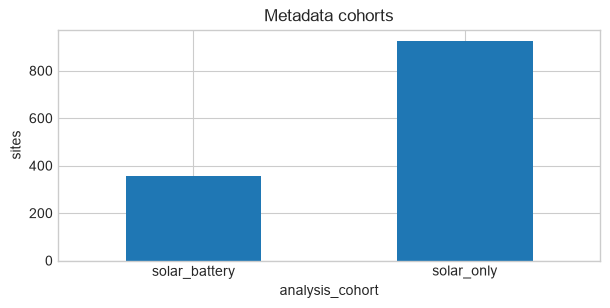

In [6]:
metadata_path = metadata_output_path(config)
metadata_quality = query(f"""
    SELECT
        analysis_cohort,
        install_phase_count,
        count(*) AS n_sites,
        count_if(solar_capacity_kw IS NULL) AS missing_solar_capacity,
        count_if(s_rated_kva IS NULL) AS missing_s_rated
    FROM read_parquet({sql_string(metadata_path)})
    GROUP BY analysis_cohort, install_phase_count
    ORDER BY analysis_cohort, install_phase_count
""")
display(metadata_quality)

cohort_counts = metadata_quality.groupby("analysis_cohort")["n_sites"].sum()
cohort_counts.plot(kind="bar", title="Metadata cohorts", ylabel="sites", rot=0, figsize=(7, 3));
plt.show()

In [7]:
# Gate 1: metadata IDs must be unique; unavailable ratings must remain explicit.
metadata_gate = query(f"""
    SELECT
        count(*) AS n_rows,
        count(DISTINCT serial) AS n_serials,
        count_if(serial IS NULL OR trim(serial) = '') AS blank_serials,
        count_if(s_rated_kva IS NOT NULL) AS inferred_ratings
    FROM read_parquet({sql_string(metadata_path)})
""")
display(metadata_gate)
assert int(metadata_gate.loc[0, "n_rows"]) == int(metadata_gate.loc[0, "n_serials"])
assert int(metadata_gate.loc[0, "blank_serials"]) == 0
assert int(metadata_gate.loc[0, "inferred_ratings"]) == 0

,n_rows,n_serials,blank_serials,inferred_ratings
0,1282,1282,0.0,0.0


## Stage 2: duplicate-key audit

The candidate key is `(serial, MeasureTime, Vphase)`. Identical duplicates can be collapsed. Conflicting duplicates are quarantined and must be inspected rather than averaged.

In [8]:
duplicate_report_path = duplicate_summary_path(config, scope)
audit_path = duplicate_audit_path(config, scope)

if duplicate_report_path.exists() and audit_path.exists() and not OVERWRITE_SAMPLE:
    duplicate_report = read_json(duplicate_report_path)
    print("Reusing existing duplicate audit. Set OVERWRITE_SAMPLE=True to rebuild.")
else:
    duplicate_report = run_duplicate_audit(config, scope, overwrite=OVERWRITE_SAMPLE)

duplicate_summary = pd.DataFrame({
    "metric": [
        "duplicate keys", "identical keys", "conflicting keys",
        "identical rows collapsed", "conflicting rows quarantined",
        "cross-file duplicate keys",
    ],
    "value": [
        duplicate_report["duplicate_keys"],
        duplicate_report["identical_duplicate_keys"],
        duplicate_report["conflicting_duplicate_keys"],
        duplicate_report["identical_rows_to_collapse"],
        duplicate_report["conflicting_rows_to_quarantine"],
        duplicate_report["cross_file_duplicate_keys"],
    ],
})
display(duplicate_summary)

Reusing existing duplicate audit. Set OVERWRITE_SAMPLE=True to rebuild.


,metric,value
0,duplicate keys,0
1,identical keys,0
2,conflicting keys,0
3,identical rows collapsed,0
4,conflicting rows quarantined,0
5,cross-file duplicate keys,0


In [9]:
duplicate_classes = query(f"""
    SELECT duplicate_class, count(*) AS n_keys, sum(row_count) AS n_source_rows
    FROM read_parquet({sql_string(audit_path)})
    GROUP BY duplicate_class
    ORDER BY duplicate_class
""")
display(duplicate_classes)
if not duplicate_classes.empty:
    duplicate_classes.set_index("duplicate_class")["n_keys"].plot(
        kind="bar", title="Repeated keys by classification", ylabel="keys", rot=0, figsize=(7, 3)
    )
    plt.show()

conflict_path = conflicting_rows_path(config, scope)
conflict_preview = query(f"""
    SELECT *
    FROM read_parquet({sql_string(conflict_path)})
    ORDER BY serial, measure_time, phase, source_file
    LIMIT 50
""")
display(conflict_preview)

,duplicate_class,n_keys,n_source_rows


,serial,measure_time,phase,voltage_v,current_a,reactive_power_raw_var,active_power_raw_w,source_month,source_file


In [10]:
# Gate 2: the duplicate audit itself must account for its classifications.
assert duplicate_report["duplicate_keys"] == (
    duplicate_report["identical_duplicate_keys"]
    + duplicate_report["conflicting_duplicate_keys"]
)
assert duplicate_report["conflicting_rows_to_quarantine"] >= (
    2 * duplicate_report["conflicting_duplicate_keys"]
)
print("Stage 2 gate passed. Review conflict_preview before continuing.")

Stage 2 gate passed. Review conflict_preview before continuing.


## Stage 3: canonical phase telemetry

This writes one row per accepted `(serial, timestamp, phase)` key. 

Raw P/Q are retained alongside provisional normalised signs, UTC/local timestamps, metadata flags and duplicate provenance.

In [11]:
canonical_report_path = canonical_build_summary_path(config, scope)
canonical_dir = canonical_output_path(config, scope)

if canonical_report_path.exists() and canonical_dir.exists() and not OVERWRITE_SAMPLE:
    canonical_report = read_json(canonical_report_path)
    print("Reusing existing canonical sample. Set OVERWRITE_SAMPLE=True to rebuild.")
else:
    canonical_report = build_canonical_phase(config, scope, overwrite=OVERWRITE_SAMPLE)

display(pd.DataFrame([canonical_report]))
canonical_glob = str(canonical_dir / "**" / "*.parquet")

Reusing existing canonical sample. Set OVERWRITE_SAMPLE=True to rebuild.


,created_utc,scope,output_directory,active_export_sign,reactive_absorbing_sign,local_timezone,n_rows,n_serials,first_timestamp_utc,last_timestamp_utc,canonical_rows_from_duplicate_keys,rows_without_metadata
0,2026-07-30T05:29:36.458855+00:00,"{'label': 'month_2025_04__bucket_0_of_32', 'mo...",C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,-1,-1,Australia/Sydney,759287,42,2025-04-01 00:00:00+00:00,2025-04-30 23:55:00+00:00,0,25920


In [12]:
canonical_quality = query(f"""
    SELECT
        phase,
        duplicate_status,
        metadata_available,
        count(*) AS n_rows,
        count(DISTINCT serial) AS n_serials,
        count_if(row_has_null_measurement) AS null_measurement_rows,
        count_if(NOT voltage_physical_ok) AS voltage_flagged_rows
    FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning = true)
    GROUP BY phase, duplicate_status, metadata_available
    ORDER BY phase, duplicate_status, metadata_available
""")
display(canonical_quality)

canonical_preview = query(f"""
    SELECT
        serial, timestamp_utc, timestamp_local, phase, voltage_v,
        active_power_raw_w, p_export_w,
        reactive_power_raw_var, q_absorbing_var, q_generator_var,
        duplicate_status, metadata_available, analysis_cohort
    FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning = true)
    ORDER BY serial, timestamp_utc, phase
    LIMIT 30
""")
display(canonical_preview)

,phase,duplicate_status,metadata_available,n_rows,n_serials,null_measurement_rows,voltage_flagged_rows
0,A,unique,False,8640,1,0.0,0.0
1,A,unique,True,349907,41,145297.0,0.0
2,B,unique,False,8640,1,0.0,0.0
3,B,unique,True,204610,24,0.0,0.0
4,C,unique,False,8640,1,0.0,0.0
5,C,unique,True,178850,21,0.0,0.0


,serial,timestamp_utc,timestamp_local,phase,voltage_v,active_power_raw_w,p_export_w,reactive_power_raw_var,q_absorbing_var,q_generator_var,duplicate_status,metadata_available,analysis_cohort
0,810140828,2025-04-01 00:00:00+00:00,2025-04-01 11:00:00,A,243.442017,35.736385,-35.736385,-25.525990,25.525990,-25.525990,unique,True,solar_only
1,810140828,2025-04-01 00:00:00+00:00,2025-04-01 11:00:00,B,241.494064,-1546.875000,1546.875000,684.096500,-684.096500,684.096500,unique,True,solar_only
2,810140828,2025-04-01 00:00:00+00:00,2025-04-01 11:00:00,C,241.947556,71.472770,-71.472770,-56.157177,56.157177,-56.157177,unique,True,solar_only
3,810140828,2025-04-01 00:05:00+00:00,2025-04-01 11:05:00,A,242.411346,35.736385,-35.736385,-25.525990,25.525990,-25.525990,unique,True,solar_only
4,810140828,2025-04-01 00:05:00+00:00,2025-04-01 11:05:00,B,241.236400,-1720.451660,1720.451660,617.728943,-617.728943,617.728943,unique,True,solar_only
5,810140828,2025-04-01 00:05:00+00:00,2025-04-01 11:05:00,C,241.421921,71.472770,-71.472770,-56.157177,56.157177,-56.157177,unique,True,solar_only
6,810140828,2025-04-01 00:10:00+00:00,2025-04-01 11:10:00,A,242.906067,35.736385,-35.736385,-25.525990,25.525990,-25.525990,unique,True,solar_only
7,810140828,2025-04-01 00:10:00+00:00,2025-04-01 11:10:00,B,241.329163,-1582.611330,1582.611330,607.518555,-607.518555,607.518555,unique,True,solar_only
8,810140828,2025-04-01 00:10:00+00:00,2025-04-01 11:10:00,C,241.473450,71.472770,-71.472770,-51.051980,51.051980,-51.051980,unique,True,solar_only
9,810140828,2025-04-01 00:15:00+00:00,2025-04-01 11:15:00,A,242.772079,35.736385,-35.736385,-25.525990,25.525990,-25.525990,unique,True,solar_only


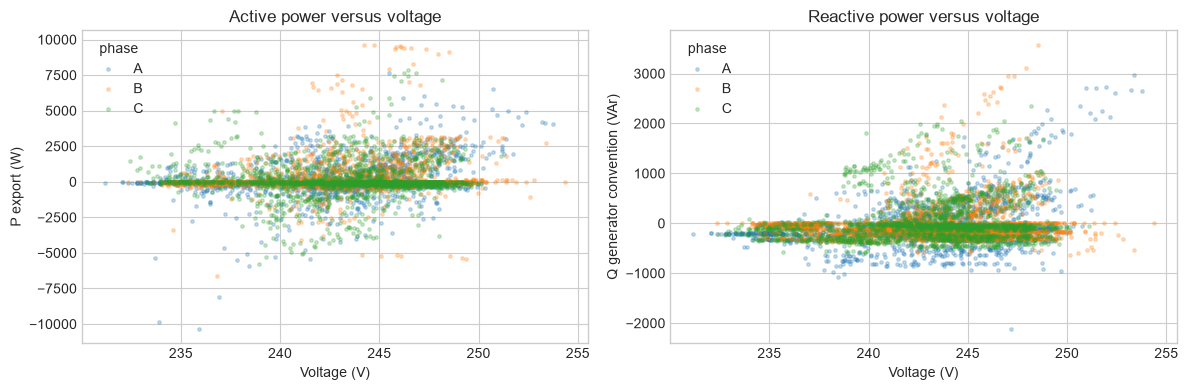

In [13]:
# Deterministic, bounded visual sample. This does not load the whole scope into pandas.
plot_sample = query(f"""
    SELECT phase, voltage_v, p_export_w, q_generator_var
    FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning = true)
    WHERE mod(hash(serial, timestamp_utc, phase), 100) = 0
      AND voltage_v IS NOT NULL
      AND p_export_w IS NOT NULL
      AND q_generator_var IS NOT NULL
    LIMIT 30000
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for phase, frame in plot_sample.groupby("phase"):
    axes[0].scatter(frame["voltage_v"], frame["p_export_w"], s=6, alpha=0.25, label=phase)
    axes[1].scatter(frame["voltage_v"], frame["q_generator_var"], s=6, alpha=0.25, label=phase)
axes[0].set(title="Active power versus voltage", xlabel="Voltage (V)", ylabel="P export (W)")
axes[1].set(title="Reactive power versus voltage", xlabel="Voltage (V)", ylabel="Q generator convention (VAr)")
for axis in axes:
    axis.legend(title="phase")
plt.tight_layout()
plt.show()

In [14]:
# Gate 3: uniqueness and timestamp conversion must hold before final validation.
canonical_gate = query(f"""
    WITH canonical AS (
        SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning = true)
    )
    SELECT
        count(*) AS n_rows,
        count_if(timestamp_utc IS NULL) AS null_utc,
        count_if(timestamp_local IS NULL) AS null_local,
        count(*) - count(DISTINCT (serial, timestamp_utc, phase)) AS duplicate_rows,
        count_if(p_export_w != active_power_raw_w * {config.assumptions.active_export_sign}) AS active_sign_errors,
        count_if(q_absorbing_var != reactive_power_raw_var * {config.assumptions.reactive_absorbing_sign}) AS reactive_sign_errors
    FROM canonical
""")
display(canonical_gate)
assert int(canonical_gate.loc[0, "null_utc"]) == 0
assert int(canonical_gate.loc[0, "null_local"]) == 0
assert int(canonical_gate.loc[0, "duplicate_rows"]) == 0
assert int(canonical_gate.loc[0, "active_sign_errors"]) == 0
assert int(canonical_gate.loc[0, "reactive_sign_errors"]) == 0

,n_rows,null_utc,null_local,duplicate_rows,active_sign_errors,reactive_sign_errors
0,759287,0.0,0.0,0,0.0,0.0


## Stage 4: exact row accounting and final sample validation

The expected canonical count is:

`source rows - collapsed identical rows - all quarantined conflicting rows`

In [15]:
validation = validate_canonical_phase(config, scope)

validation_headline = {
    key: value
    for key, value in validation.items()
    if key not in {"monthly_coverage", "scope", "failures"}
}
display(pd.DataFrame([validation_headline]).T.rename(columns={0: "value"}))
display(pd.DataFrame(validation["monthly_coverage"]))

assert validation["status"] == "pass"
assert validation["accounting_difference"] == 0
assert validation["duplicate_keys_remaining"] == 0

2026-07-30 15:54:32,317 | INFO | Canonical validation PASS: accounting difference=0, duplicate keys=0


,value
created_utc,2026-07-30T05:54:32.313003+00:00
status,pass
source_rows,759287
identical_rows_collapsed,0
conflicting_rows_quarantined,0
conflicting_duplicate_keys,0
expected_canonical_rows,759287
accounting_difference,0
canonical_rows,759287
canonical_serials,42


,year_utc,month_utc,n_rows,n_serials
0,2025,4,759287,42


In [16]:
# Final sample decision table.
sample_decision = pd.DataFrame({
    "gate": [
        "source inventory", "metadata uniqueness", "duplicate accounting",
        "canonical uniqueness", "final row accounting",
    ],
    "passed": [
        bool(inventory_gate["passed"].all()),
        int(metadata_gate.loc[0, "n_rows"]) == int(metadata_gate.loc[0, "n_serials"]),
        duplicate_report["duplicate_keys"] == duplicate_report["identical_duplicate_keys"] + duplicate_report["conflicting_duplicate_keys"],
        int(canonical_gate.loc[0, "duplicate_rows"]) == 0,
        validation["status"] == "pass" and validation["accounting_difference"] == 0,
    ],
})
display(sample_decision)
assert sample_decision["passed"].all()
print("Sample foundation pipeline passed. Review the tables and plots before widening scope.")

,gate,passed
0,source inventory,True
1,metadata uniqueness,True
2,duplicate accounting,True
3,canonical uniqueness,True
4,final row accounting,True


Sample foundation pipeline passed. Review the tables and plots before widening scope.


In [17]:
null_breakdown = query(f"""
    SELECT
        phase,
        count(*) AS n_rows,
        count_if(voltage_v IS NULL) AS null_voltage,
        count_if(current_a IS NULL) AS null_current,
        count_if(active_power_raw_w IS NULL) AS null_active_power,
        count_if(reactive_power_raw_var IS NULL) AS null_reactive_power,
        count_if(row_has_null_measurement) AS any_null_measurement
    FROM read_parquet(
        {sql_string(canonical_glob)},
        hive_partitioning = true
    )
    GROUP BY phase
    ORDER BY phase
""")

display(null_breakdown)

,phase,n_rows,null_voltage,null_current,null_active_power,null_reactive_power,any_null_measurement
0,A,358547,0.0,0.0,145297.0,145297.0,145297.0
1,B,213250,0.0,0.0,0.0,0.0,0.0
2,C,187490,0.0,0.0,0.0,0.0,0.0


# Full-dataset build

The full build may take substantial time and temporary disk. The following exact confirmation prevents accidental execution.

In [18]:
FULL_RUN_CONFIRMATION = "RUN FULL DATASET"  # Change to: RUN FULL DATASET
OVERWRITE_FULL = True

assert FULL_RUN_CONFIRMATION == "RUN FULL DATASET", (
    "Full run remains locked. Review the complete sample first."
)
full_scope = config.scope(None, None)
print("Full run unlocked:", full_scope.label)

Full run unlocked: full


## Full Stage 0: inventory

In [19]:
full_inventory = run_inventory(config, full_scope)
display(pd.DataFrame([full_inventory["overall"]]))
display(pd.DataFrame(full_inventory["by_source_month"]))
assert full_inventory["overall"]["null_timestamps"] == 0
assert full_inventory["overall"]["null_or_blank_serials"] == 0

2026-07-30 15:54:32,518 | INFO | Inventorying source scope: full


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 15:54:53,148 | INFO | Source inventory written to C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\_manifests\source_inventory.json


,n_rows,n_serials,first_measure_time,last_measure_time,n_phases,n_source_months,n_source_files,null_timestamps,null_or_blank_serials
0,303647633,1342,2024-08-01,2025-07-31 23:55:00,3,12,12,0,0


,source_month,n_rows,n_serials,first_measure_time,last_measure_time
0,2024-08,24409491,1327,2024-08-01,2024-08-31 23:55:00
1,2024-09,23314158,1327,2024-09-01,2024-09-30 23:55:00
2,2024-10,25207827,1338,2024-10-01,2024-10-31 23:55:00
3,2024-11,36261493,1338,2024-11-01,2024-11-30 23:55:00
4,2024-12,24692114,1338,2024-12-01,2024-12-31 23:55:00
5,2025-01,25747561,1336,2025-01-01,2025-01-31 23:55:00
6,2025-02,21987966,1336,2025-02-01,2025-02-28 23:55:00
7,2025-03,26714043,1336,2025-03-01,2025-03-31 23:55:00
8,2025-04,23116030,1336,2025-04-01,2025-04-30 23:55:00
9,2025-05,24199611,1336,2025-05-01,2025-05-31 23:55:00


## Full Stage 1: metadata and complete ID reconciliation

In [20]:
full_metadata_summary_path = metadata_summary_path(config, full_scope)
full_reconciliation_path = reconciliation_output_path(config, full_scope)
if full_metadata_summary_path.exists() and full_reconciliation_path.exists() and not OVERWRITE_FULL:
    full_metadata = read_json(full_metadata_summary_path)
else:
    full_metadata = prepare_metadata(config, full_scope, overwrite=OVERWRITE_FULL)
display(pd.DataFrame([full_metadata["reconciliation_counts"]]).fillna(0))
display(pd.read_csv(full_reconciliation_path).query("reconciliation_status != 'matched'").head(100))

2026-07-30 15:54:53,201 | INFO | Reading metadata workbook: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\ausgrid_meta.xlsx


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 15:54:57,461 | INFO | Canonical metadata written to C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\metadata\metadata_canonical.parquet
2026-07-30 15:54:57,461 | INFO | ID reconciliation: {'matched': 1282, 'telemetry_only': 60}


,matched,telemetry_only
0,1282,60


,serial,in_telemetry,in_metadata,reconciliation_status
1282,810021485,True,False,telemetry_only
1283,810133679,True,False,telemetry_only
1284,810212355,True,False,telemetry_only
1285,810233177,True,False,telemetry_only
1286,810266688,True,False,telemetry_only
1287,810269130,True,False,telemetry_only
1288,810357302,True,False,telemetry_only
1289,810383879,True,False,telemetry_only
1290,810398964,True,False,telemetry_only
1291,810488750,True,False,telemetry_only


## Full Stage 2: duplicate audit

In [21]:
full_duplicate_summary_path = duplicate_summary_path(config, full_scope)
if full_duplicate_summary_path.exists() and duplicate_audit_path(config, full_scope).exists() and not OVERWRITE_FULL:
    full_duplicates = read_json(full_duplicate_summary_path)
else:
    full_duplicates = run_duplicate_audit(config, full_scope, overwrite=OVERWRITE_FULL)
display(pd.DataFrame([full_duplicates]).T.rename(columns={0: "value"}))
assert full_duplicates["duplicate_keys"] == full_duplicates["identical_duplicate_keys"] + full_duplicates["conflicting_duplicate_keys"]

2026-07-30 15:54:57,575 | INFO | Auditing duplicate keys for scope: full
2026-07-30 15:54:57,614 | INFO | Auditing duplicate keys for 2024-08


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 15:55:20,700 | INFO | Auditing duplicate keys for 2024-09


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 15:55:46,254 | INFO | Auditing duplicate keys for 2024-10


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 16:03:33,142 | INFO | Auditing duplicate keys for 2025-07


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 16:04:56,249 | WARNING | Could not remove temporary duplicate chunks at C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\_duckdb\tmp\duplicate_chunks_full_f19e1e12a79b4fc98d1fb23ac346a4e1: [WinError 5] Access is denied: 'C:\\Users\\z3553082\\OneDrive - UNSW\\Documents\\CICCADA - Data\\Ausgrid\\derived\\_duckdb\\tmp\\duplicate_chunks_full_f19e1e12a79b4fc98d1fb23ac346a4e1'
2026-07-30 16:04:56,253 | INFO | Duplicate audit written to C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\audit\duplicate_key_audit.parquet
2026-07-30 16:04:56,255 | INFO | Duplicate keys=1423089; identical=1423089; conflicting=0


,value
created_utc,2026-07-30T06:04:56.250828+00:00
scope,"{'label': 'full', 'month': None, 'site_bucket'..."
float_tolerance,0.000001
duplicate_keys,1423089
rows_in_duplicate_keys,20982983
repeated_rows_above_one_per_key,19559894
identical_duplicate_keys,1423089
conflicting_duplicate_keys,0
identical_rows_to_collapse,19559894
conflicting_rows_to_quarantine,0


## Full Stage 3: canonical phase telemetry

In [22]:
full_canonical_summary_path = canonical_build_summary_path(config, full_scope)
if full_canonical_summary_path.exists() and canonical_output_path(config, full_scope).exists() and not OVERWRITE_FULL:
    full_canonical = read_json(full_canonical_summary_path)
else:
    full_canonical = build_canonical_phase(config, full_scope, overwrite=OVERWRITE_FULL)
display(pd.DataFrame([full_canonical]).T.rename(columns={0: "value"}))

2026-07-30 16:04:56,298 | INFO | Building canonical phase parquet for scope: full


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 16:50:35,452 | INFO | Canonical phase parquet written to C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase
2026-07-30 16:50:35,452 | INFO | Canonical rows=284087739; serials=1342


,value
created_utc,2026-07-30T06:50:35.443961+00:00
scope,"{'label': 'full', 'month': None, 'site_bucket'..."
output_directory,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...
active_export_sign,-1
reactive_absorbing_sign,-1
local_timezone,Australia/Sydney
n_rows,284087739
n_serials,1342
first_timestamp_utc,2024-08-01 00:00:00+00:00
last_timestamp_utc,2025-07-31 23:55:00+00:00


## Full Stage 4: validation

In [23]:
full_validation = validate_canonical_phase(config, full_scope)
display(pd.DataFrame([{k: v for k, v in full_validation.items() if k != "monthly_coverage"}]).T.rename(columns={0: "value"}))
display(pd.DataFrame(full_validation["monthly_coverage"]))
assert full_validation["status"] == "pass"
assert full_validation["accounting_difference"] == 0
assert full_validation["duplicate_keys_remaining"] == 0
print("Delivery 1 full foundation build passed.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-07-30 17:08:04,402 | INFO | Canonical validation PASS: accounting difference=0, duplicate keys=0


,value
created_utc,2026-07-30T07:08:04.387138+00:00
scope,"{'label': 'full', 'month': None, 'site_bucket'..."
status,pass
failures,[]
source_rows,303647633
identical_rows_collapsed,19559894
conflicting_rows_quarantined,0
conflicting_duplicate_keys,0
expected_canonical_rows,284087739
accounting_difference,0


,year_utc,month_utc,n_rows,n_serials
0,2024,8,24002529,1327
1,2024,9,23219460,1327
2,2024,10,24094143,1338
3,2024,11,23441850,1338
4,2024,12,24197054,1338
5,2025,1,24194796,1336
6,2025,2,21853440,1336
7,2025,3,24194829,1336
8,2025,4,23085505,1336
9,2025,5,24194880,1336


Delivery 1 full foundation build passed.


In [24]:
full_reconciliation_path = reconciliation_output_path(config, full_scope)

full_reconciliation = pd.read_csv(
    full_reconciliation_path,
    dtype={"serial": "string"},
)

full_reconciliation_counts = (
    full_reconciliation
    .groupby("reconciliation_status", dropna=False)
    .size()
    .rename("n_ids")
    .to_frame()
)

display(full_reconciliation_counts)

# Show every unmatched ID
display(
    full_reconciliation.query(
        "reconciliation_status != 'matched'"
    )
)

,n_ids
reconciliation_status,
matched,1282
telemetry_only,60


,serial,in_telemetry,in_metadata,reconciliation_status
1282,810021485,True,False,telemetry_only
1283,810133679,True,False,telemetry_only
1284,810212355,True,False,telemetry_only
1285,810233177,True,False,telemetry_only
1286,810266688,True,False,telemetry_only
1287,810269130,True,False,telemetry_only
1288,810357302,True,False,telemetry_only
1289,810383879,True,False,telemetry_only
1290,810398964,True,False,telemetry_only
1291,810488750,True,False,telemetry_only


In [25]:
full_duplicate_summary_path = duplicate_summary_path(
    config,
    full_scope,
)

full_duplicates = read_json(full_duplicate_summary_path)

display(
    pd.DataFrame([full_duplicates])
    .T
    .rename(columns={0: "value"})
)

,value
created_utc,2026-07-30T06:04:56.250828+00:00
scope,"{'label': 'full', 'month': None, 'site_bucket'..."
float_tolerance,0.000001
duplicate_keys,1423089
rows_in_duplicate_keys,20982983
repeated_rows_above_one_per_key,19559894
identical_duplicate_keys,1423089
conflicting_duplicate_keys,0
identical_rows_to_collapse,19559894
conflicting_rows_to_quarantine,0


In [26]:
full_canonical_glob = str(
    canonical_output_path(config, full_scope)
    / "**"
    / "*.parquet"
)

nulls_by_phase = query(f"""
    SELECT
        coalesce(phase, 'ALL') AS phase,
        count(*) AS n_rows,

        count_if(voltage_v IS NULL) AS null_voltage,
        round(
            100.0 * count_if(voltage_v IS NULL) / count(*),
            2
        ) AS null_voltage_pct,

        count_if(current_a IS NULL) AS null_current,
        round(
            100.0 * count_if(current_a IS NULL) / count(*),
            2
        ) AS null_current_pct,

        count_if(active_power_raw_w IS NULL) AS null_active_power,
        round(
            100.0 * count_if(active_power_raw_w IS NULL) / count(*),
            2
        ) AS null_active_power_pct,

        count_if(reactive_power_raw_var IS NULL) AS null_reactive_power,
        round(
            100.0 * count_if(reactive_power_raw_var IS NULL) / count(*),
            2
        ) AS null_reactive_power_pct,

        count_if(row_has_null_measurement) AS any_null_measurement,
        round(
            100.0 * count_if(row_has_null_measurement) / count(*),
            2
        ) AS any_null_pct

    FROM read_parquet(
        {sql_string(full_canonical_glob)},
        hive_partitioning = true
    )
    GROUP BY GROUPING SETS ((phase), ())
    ORDER BY
        CASE WHEN phase = 'ALL' THEN 1 ELSE 0 END,
        phase
""")

display(nulls_by_phase)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,phase,n_rows,null_voltage,null_voltage_pct,null_current,null_current_pct,null_active_power,null_active_power_pct,null_reactive_power,null_reactive_power_pct,any_null_measurement,any_null_pct
0,A,140069836,0.0,0.0,4410136.0,3.15,64139491.0,45.79,64139491.0,45.79,66449683.0,47.44
1,ALL,284087739,0.0,0.0,9030520.0,3.18,64139491.0,22.58,64139491.0,22.58,71070067.0,25.02
2,B,75930345,0.0,0.0,2310192.0,3.04,0.0,0.00,0.0,0.00,2310192.0,3.04
3,C,68087558,0.0,0.0,2310192.0,3.39,0.0,0.00,0.0,0.00,2310192.0,3.39


In [27]:
full_audit_path = duplicate_audit_path(config, full_scope)

duplicate_multiplicity = query(f"""
    SELECT
        row_count AS copies_per_key,
        count(*) AS n_keys,
        sum(row_count - 1) AS collapsed_rows
    FROM read_parquet({sql_string(full_audit_path)})
    GROUP BY row_count
    ORDER BY row_count
""")

duplicate_months = query(f"""
    SELECT
        year(measure_time) AS year,
        month(measure_time) AS month,
        count(*) AS duplicate_keys,
        sum(row_count - 1) AS collapsed_rows,
        max(row_count) AS maximum_copies
    FROM read_parquet({sql_string(full_audit_path)})
    GROUP BY year(measure_time), month(measure_time)
    ORDER BY year, month
""")

display(duplicate_multiplicity)
display(duplicate_months)

,copies_per_key,n_keys,collapsed_rows
0,2,1728,1728.0
1,3,288,576.0
2,4,1161703,3485109.0
3,8,6696,46872.0
4,9,579,4632.0
5,16,238635,3579525.0
6,64,1,63.0
7,81,11356,908480.0
8,100,609,60291.0
9,121,85,10200.0


,year,month,duplicate_keys,collapsed_rows,maximum_copies
0,2024,8,36434,406962.0,16
1,2024,9,29754,94698.0,16
2,2024,10,50968,1113684.0,81
3,2024,11,1074488,12819643.0,10000
4,2024,12,1363,495060.0,10000
5,2025,1,3800,1552765.0,10000
6,2025,2,9110,134526.0,16
7,2025,3,205070,2519214.0,81
8,2025,4,2219,30525.0,16
9,2025,5,365,4731.0,16


In [28]:
site_phase_null_patterns = query(f"""
    WITH site_phase AS (
        SELECT
            serial,
            phase,
            coalesce(max(analysis_cohort), 'no_metadata') AS cohort,
            max(install_phase_count) AS install_phase_count,
            count(*) AS n_rows,
            count_if(active_power_raw_w IS NULL) AS null_p,
            count_if(reactive_power_raw_var IS NULL) AS null_q,
            count_if(current_a IS NULL) AS null_i
        FROM read_parquet(
            {sql_string(full_canonical_glob)},
            hive_partitioning = true
        )
        GROUP BY serial, phase
    )
    SELECT
        phase,
        cohort,
        install_phase_count,
        count(*) AS n_site_phase_pairs,
        count_if(null_p = n_rows) AS p_always_null_sites,
        count_if(null_p = 0) AS p_never_null_sites,
        count_if(null_p > 0 AND null_p < n_rows) AS p_partially_null_sites,
        count_if(null_p != null_q) AS p_q_missingness_mismatch_sites,
        count_if(null_i = n_rows) AS current_always_null_sites,
        count_if(null_i > 0 AND null_i < n_rows)
            AS current_partially_null_sites
    FROM site_phase
    GROUP BY phase, cohort, install_phase_count
    ORDER BY phase, cohort, install_phase_count
""")

display(site_phase_null_patterns)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,phase,cohort,install_phase_count,n_site_phase_pairs,p_always_null_sites,p_never_null_sites,p_partially_null_sites,p_q_missingness_mismatch_sites,current_always_null_sites,current_partially_null_sites
0,A,no_metadata,<NA>,60,8.0,52.0,0.0,0.0,3.0,0.0
1,A,solar_battery,1,184,131.0,53.0,0.0,0.0,11.0,0.0
2,A,solar_battery,2,4,3.0,1.0,0.0,0.0,0.0,0.0
3,A,solar_battery,3,167,18.0,149.0,0.0,0.0,7.0,0.0
4,A,solar_only,1,628,436.0,192.0,0.0,0.0,12.0,0.0
5,A,solar_only,2,4,0.0,4.0,0.0,0.0,0.0,0.0
6,A,solar_only,3,295,17.0,278.0,0.0,0.0,9.0,0.0
7,B,no_metadata,<NA>,52,0.0,52.0,0.0,0.0,3.0,0.0
8,B,solar_battery,1,53,0.0,53.0,0.0,0.0,3.0,0.0
9,B,solar_battery,2,1,0.0,1.0,0.0,0.0,0.0,0.0


In [29]:
voltage_flags = query(f"""
    SELECT
        phase,
        count(*) AS n_rows,
        count_if(voltage_v <= 0) AS voltage_at_or_below_zero,
        count_if(voltage_v > 300) AS voltage_above_300,
        min(voltage_v) AS minimum_voltage,
        max(voltage_v) AS maximum_voltage
    FROM read_parquet(
        {sql_string(full_canonical_glob)},
        hive_partitioning = true
    )
    GROUP BY phase
    ORDER BY phase
""")

display(voltage_flags)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,phase,n_rows,voltage_at_or_below_zero,voltage_above_300,minimum_voltage,maximum_voltage
0,A,140069836,130319.0,0.0,0.0,266.302063
1,B,75930345,1273678.0,0.0,0.0,263.034882
2,C,68087558,638272.0,0.0,0.0,259.530600


## Delivery 1 complete

The next notebook will consume `canonical_phase` and build structured site-interval features. Volt-VAr and Volt-Watt result tables are not produced until their observability, phase aggregation, rating and irradiance dependencies have been made explicit.